<a href="https://colab.research.google.com/github/gobi2001-2006/computer-vision/blob/main/SEGMENTATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter threshold value (0-255): 190


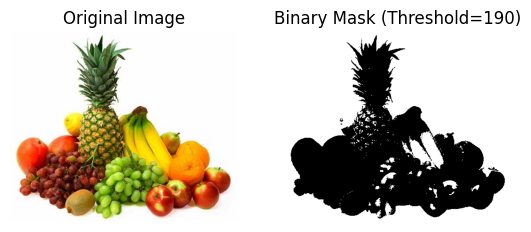

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread("fruit.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

# Convert to grayscale manually
def rgb_to_grayscale(image):
    gray_image = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            r, g, b = image[i, j]
            gray_image[i, j] = int(0.2989 * r + 0.5870 * g + 0.1140 * b)  # Standard grayscale formula
    return gray_image

gray = rgb_to_grayscale(image)

# Get threshold value from user
threshold_value = int(input("Enter threshold value (0-255): "))

# Apply thresholding manually
binary_mask = np.zeros_like(gray, dtype=np.uint8)
for i in range(gray.shape[0]):
    for j in range(gray.shape[1]):
        if gray[i, j] > threshold_value:
            binary_mask[i, j] = 255  # Foreground (White)
        else:
            binary_mask[i, j] = 0  # Background (Black)



# Display the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title(f"Binary Mask (Threshold={threshold_value})")
plt.imshow(binary_mask, cmap="gray")
plt.axis("off")

plt.show()


Enter number of clusters (e.g., 3, 4, 5): 3


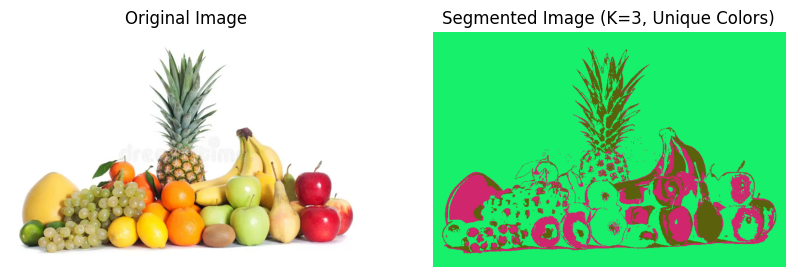

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

image = cv2.imread("fruit.webp")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

pixels = image.reshape(-1, 3)

K = int(input("Enter number of clusters (e.g., 3, 4, 5): "))

random_indices = random.sample(range(len(pixels)), K)
centroids = np.array([pixels[i] for i in random_indices])  # Select K random pixels as initial centroids

# K-Means Clustering (Iterative)
max_iters = 10  # Number of iterations
for _ in range(max_iters):
    # Step 2: Assign each pixel to the nearest centroid
    clusters = np.zeros(len(pixels))
    for i in range(len(pixels)):
        distances = [np.linalg.norm(pixels[i] - centroid) for centroid in centroids]
        clusters[i] = np.argmin(distances)  # Assign to nearest centroid

    # Step 3: Update centroids
    new_centroids = np.zeros_like(centroids)
    for k in range(K):
        cluster_points = pixels[clusters == k]
        if len(cluster_points) > 0:
            new_centroids[k] = np.mean(cluster_points, axis=0)  # Compute new centroid

    # Check for convergence
    if np.all(centroids == new_centroids):
        break
    centroids = new_centroids

random_colors = np.random.randint(0, 255, size=(K, 3))
segmented_pixels = np.zeros_like(pixels)
for i in range(len(pixels)):
    segmented_pixels[i] = random_colors[int(clusters[i])]

# Reshape back to the original image dimensions
segmented_image = segmented_pixels.reshape(image.shape)

# Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title(f"Segmented Image (K={K}, Unique Colors)")
plt.imshow(segmented_image)
plt.axis("off")

plt.show()


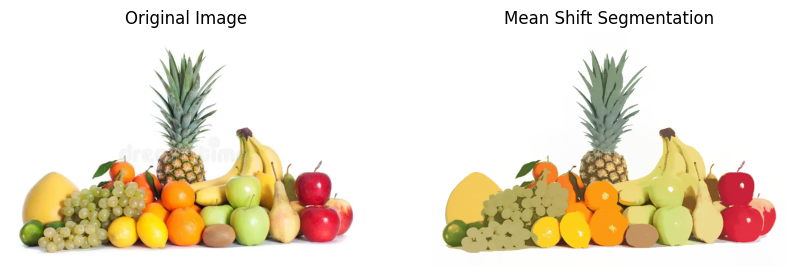

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread("fruit.webp")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

# Apply Mean Shift Segmentation
spatial_radius = 50  # Controls the spatial window (higher = more merging)
color_radius = 50    # Controls color grouping (higher = smoother regions)

segmented = cv2.pyrMeanShiftFiltering(image, sp=spatial_radius, sr=color_radius)

# Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Mean Shift Segmentation")
plt.imshow(segmented)
plt.axis("off")

plt.show()


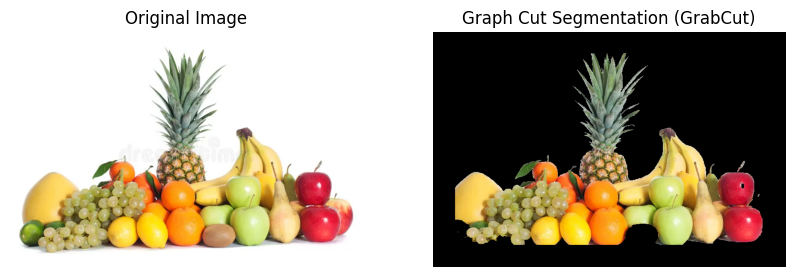

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread("fruit.webp")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Create an initial mask (same size as image, filled with probable background)
mask = np.zeros(image.shape[:2], np.uint8)

# Define background and foreground models (required by GrabCut)
bg_model = np.zeros((1, 65), np.float64)
fg_model = np.zeros((1, 65), np.float64)

# Define a rectangle around the object (x, y, width, height) - Adjust manually
rect = (50, 50, image.shape[1]-100, image.shape[0]-100)  # Adjust based on the image

# Apply GrabCut algorithm
cv2.grabCut(image, mask, rect, bg_model, fg_model, iterCount=5, mode=cv2.GC_INIT_WITH_RECT)

# Modify the mask: Set sure foreground (1, 3) and sure background (0, 2)
mask_final = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

# Apply mask to extract the object
segmented_image = image * mask_final[:, :, np.newaxis]

# Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Graph Cut Segmentation (GrabCut)")
plt.imshow(segmented_image)
plt.axis("off")

plt.show()


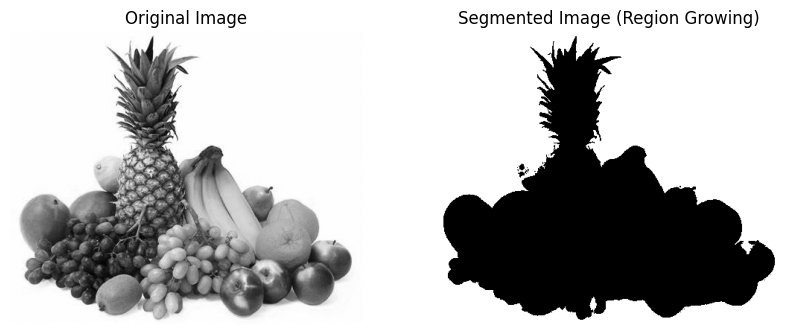

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
image_path = "fruit.jpg"  # Use raw string for Windows paths
image = Image.open(image_path).convert("L")  # Convert to grayscale
image_np = np.array(image)
seed_x, seed_y = 11, 12 # Change as needed
threshold = 50
segmented = np.zeros_like(image_np, dtype=np.uint8)
stack = [(seed_x, seed_y)]
visited = set()  # To track visited pixels
height, width = image_np.shape
neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]
while stack:
    x, y = stack.pop()
    if (x, y) in visited:
        continue
    visited.add((x, y))
    if abs(int(image_np[x, y]) - int(image_np[seed_x, seed_y])) < threshold:
        segmented[x, y] = 255  # Mark as foreground

        # Add neighbors to the stack
        for dx, dy in neighbors:
            nx, ny = x + dx, y + dy
            if 0 <= nx < height and 0 <= ny < width and (nx, ny) not in visited:
                stack.append((nx, ny))
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_np, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(segmented, cmap="gray")
plt.title("Segmented Image (Region Growing)")
plt.axis("off")
plt.show()


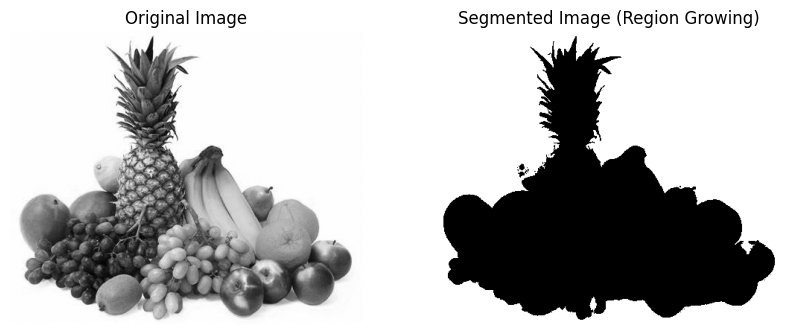

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
image_path ="fruit.jpg"   # Use raw string for Windows paths
image = Image.open(image_path).convert("L")  # Convert to grayscale
image_np = np.array(image)
seed_x, seed_y = 150, 120 # Change as needed
threshold = 50
segmented = np.zeros_like(image_np, dtype=np.uint8)
stack = [(seed_x, seed_y)]
visited = set()  # To track visited pixels
height, width = image_np.shape
neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]
while stack:
    x, y = stack.pop()
    if (x, y) in visited:
        continue
    visited.add((x, y))
    if abs(int(image_np[x, y]) - int(image_np[seed_x, seed_y])) < threshold:
        segmented[x, y] = 255  # Mark as foreground

        # Add neighbors to the stack
        for dx, dy in neighbors:
            nx, ny = x + dx, y + dy
            if 0 <= nx < height and 0 <= ny < width and (nx, ny) not in visited:
                stack.append((nx, ny))
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_np, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(segmented, cmap="gray")
plt.title("Segmented Image (Region Growing)")
plt.axis("off")
plt.show()
